**Hyperliquid Trader Behavior vs Market Sentiment Analysis**

**Objective**

Analyze how market sentiment (Fear & Greed Index) relates to trader behavior and performance on Hyperliquid.

We aim to:
- Examine performance differences across sentiment regimes
- Understand behavioral changes during Fear vs Greed
- Identify trader segments
- Extract actionable trading insights


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Loading**

In [ ]:
fear_greed = pd.read_csv("fear_greed_index.csv")

trades = pd.read_csv("historical_data.csv")

print("Fear & Greed shape:", fear_greed.shape)

print("Trades shape:", trades.shape)

Fear & Greed shape: (2644, 4)
Trades shape: (211224, 16)


# **Data Validation**

In [8]:
print("Fear & Greed Info")

print(fear_greed.info())

Fear & Greed Info
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None


In [7]:
print("Trades Info")

print(trades.info())

Trades Info
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64

In [10]:
print("Missing Values — Fear & Greed")

print(fear_greed.isnull().sum())

Missing Values — Fear & Greed
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [11]:
print("Missing Values — Trades")

print(trades.isnull().sum())

Missing Values — Trades
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [14]:
print("Duplicate Rows — Fear & Greed:", fear_greed.duplicated().sum())

Duplicate Rows — Fear & Greed: 0


In [13]:
print("Duplicate Rows — Trades:", trades.duplicated().sum())

Duplicate Rows — Trades: 0


# **Timestamp Conversion & Daily Alignment**

In [16]:
# Convert Fear & Greed date column

fear_greed["date"] = pd.to_datetime(fear_greed["date"])

In [17]:
# Convert Trades timestamp (using Timestamp IST column)

trades["date"] = pd.to_datetime(trades["Timestamp IST"],dayfirst=True)

In [18]:
# Convert to daily level
trades["date"] = trades["date"].dt.date
trades["date"] = pd.to_datetime(trades["date"])

In [19]:
print("Fear & Greed date type:", fear_greed["date"].dtype)
print("Trades date type:", trades["date"].dtype)

Fear & Greed date type: datetime64[us]
Trades date type: datetime64[s]


In [20]:
print("Trade date null values:", trades["date"].isnull().sum())

Trade date null values: 0


# **Daily Account-Level Metrics**

In [21]:
# DAILY PnL PER ACCOUNT

daily_pnl = (trades
    .groupby(["date", "Account"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.rename(columns={"Closed PnL": "daily_pnl"}, inplace=True)

daily_pnl.head()

,date,Account,daily_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [23]:
# DAILY WIN RATE

trades["win"] = np.where(trades["Closed PnL"] > 0, 1, 0)

daily_winrate = (
    trades
    .groupby(["date", "Account"])["win"]
    .mean()
    .reset_index()
)

daily_winrate.rename(columns={"win": "win_rate"}, inplace=True)

daily_winrate.head()

,date,Account,win_rate
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.363636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [24]:
# AVERAGE TRADE SIZE

daily_avg_size = (
    trades
    .groupby(["date", "Account"])["Size USD"]
    .mean()
    .reset_index()
)

daily_avg_size.rename(columns={"Size USD": "avg_trade_size_usd"}, inplace=True)

daily_avg_size.head()

,date,Account,avg_trade_size_usd
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5556.203333
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,10291.213636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5304.975000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5116.256667


In [25]:
# TRADES PER DAY

daily_trade_count = (
    trades
    .groupby(["date", "Account"])
    .size()
    .reset_index(name="trades_per_day")
)

daily_trade_count.head()

,date,Account,trades_per_day
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3


In [26]:
# MERGE ALL METRICS

account_daily = daily_pnl.merge(daily_winrate, on=["date", "Account"])
account_daily = account_daily.merge(daily_avg_size, on=["date", "Account"])
account_daily = account_daily.merge(daily_trade_count, on=["date", "Account"])

account_daily.head()

,date,Account,daily_pnl,win_rate,avg_trade_size_usd,trades_per_day
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,0.363636,10291.213636,11
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,0.000000,5304.975000,2
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5116.256667,3


In [27]:
# MERGE WITH SENTIMENT DATA

# only required columns from sentiment dataset
sentiment = fear_greed[["date", "value", "classification"]]

merged = account_daily.merge(
    sentiment,
    on="date",
    how="left"
)

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (2341, 8)


,date,Account,daily_pnl,win_rate,avg_trade_size_usd,trades_per_day,value,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,63.0,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,75.0,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,0.363636,10291.213636,11,72.0,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,0.000000,5304.975000,2,70.0,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5116.256667,3,67.0,Greed


In [28]:
print("Missing sentiment values:", merged["classification"].isnull().sum())

Missing sentiment values: 1


In [29]:
merged[merged["classification"].isnull()]

,date,Account,daily_pnl,win_rate,avg_trade_size_usd,trades_per_day,value,classification
482,2024-10-26,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,42471.99413,1.0,14778.143333,6,NaN,NaN


In [30]:
# Removing missing sentiment rows
merged = merged.dropna(subset=["classification"])

In [31]:
print("Missing sentiment values:", merged["classification"].isnull().sum())

Missing sentiment values: 0


# **ANALYSIS 1**

In [32]:
merged["classification"].value_counts()

classification
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64

In [33]:
# Simplify sentiment into 3 regimes
def simplify_sentiment(x):
    if "Fear" in x:
        return "Fear"
    elif "Greed" in x:
        return "Greed"
    else:
        return "Neutral"

merged["sentiment_group"] = merged["classification"].apply(simplify_sentiment)

merged["sentiment_group"].value_counts()

sentiment_group
Greed      1174
Fear        790
Neutral     376
Name: count, dtype: int64

In [ ]:
# Comparing Performance Across Regimes
performance_by_sentiment = (
    merged
    .groupby("sentiment_group")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades_per_day=("trades_per_day", "mean")
    )
    .reset_index()
)

performance_by_sentiment

,sentiment_group,avg_daily_pnl,avg_win_rate,avg_trades_per_day
0,Fear,5185.146443,0.357071,105.363291
1,Greed,4144.208334,0.362748,76.912266
2,Neutral,3438.618818,0.355414,100.228723


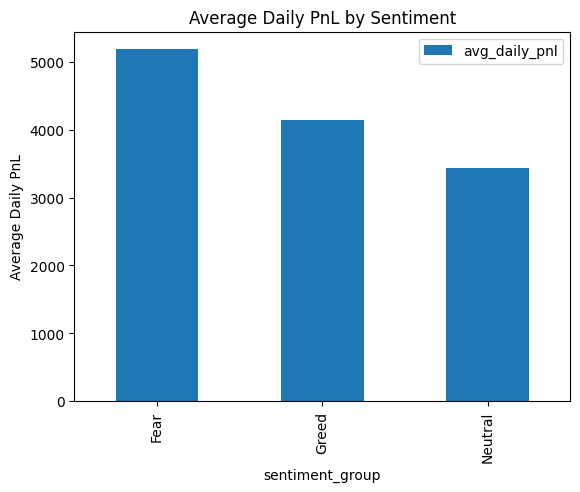

In [35]:
# Visualize

import matplotlib.pyplot as plt

performance_by_sentiment.plot(
    x="sentiment_group",
    y="avg_daily_pnl",
    kind="bar"
)

plt.title("Average Daily PnL by Sentiment")
plt.ylabel("Average Daily PnL")
plt.show()

# **ANALYSIS 2**

In [38]:
# Behavioral Comparison Table

behavior_by_sentiment = (
    merged
    .groupby("sentiment_group")
    .agg(
        avg_trades_per_day=("trades_per_day", "mean"),
        avg_trade_size=("avg_trade_size_usd", "mean"),
        avg_win_rate=("win_rate", "mean")
    )
    .reset_index()
)

behavior_by_sentiment

,sentiment_group,avg_trades_per_day,avg_trade_size,avg_win_rate
0,Fear,105.363291,8529.859802,0.357071
1,Greed,76.912266,5954.632633,0.362748
2,Neutral,100.228723,6963.694861,0.355414


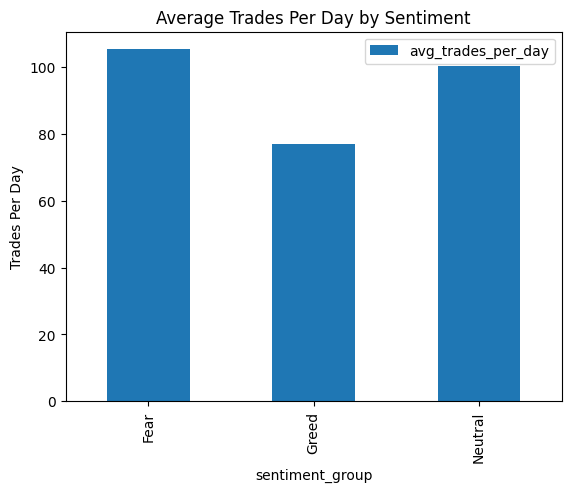

In [37]:
behavior_by_sentiment.plot(
    x="sentiment_group",
    y="avg_trades_per_day",
    kind="bar"
)

plt.title("Average Trades Per Day by Sentiment")
plt.ylabel("Trades Per Day")
plt.show()

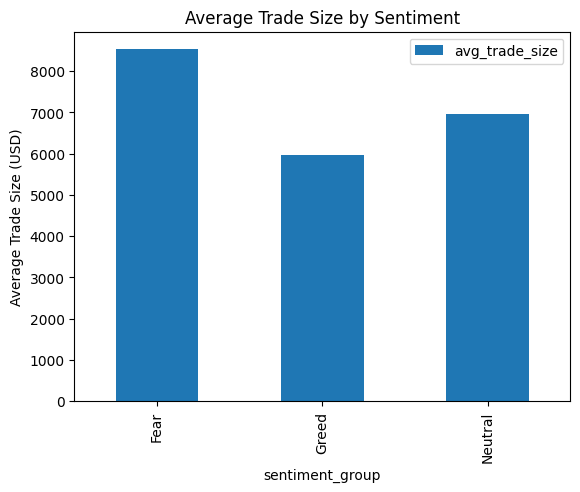

In [39]:
behavior_by_sentiment.plot(
    x="sentiment_group",
    y="avg_trade_size",
    kind="bar"
)

plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

In [41]:
# LONG / SHORT ANALYSIS BY SENTIMENT

trades_with_sentiment = trades.merge(
    fear_greed[["date", "classification"]],
    on="date",
    how="left"
)

trades_with_sentiment = trades_with_sentiment.dropna(subset=["classification"])

# 3. Simplify sentiment
def simplify_sentiment(x):
    if "Fear" in x:
        return "Fear"
    elif "Greed" in x:
        return "Greed"
    else:
        return "Neutral"

trades_with_sentiment["sentiment_group"] = (
    trades_with_sentiment["classification"].apply(simplify_sentiment)
)

# 4. Long/Short distribution
long_short = (
    trades_with_sentiment
    .groupby(["sentiment_group", "Side"])
    .size()
    .unstack(fill_value=0)
)

long_short

Side,BUY,SELL
sentiment_group,,
Fear,41205,42032
Greed,42516,47779
Neutral,18969,18717


# **SEGMENTATION**

In [42]:
# SEGMENT 1: ACTIVITY LEVEL

account_activity = (
    merged
    .groupby("Account")["trades_per_day"]
    .mean()
    .reset_index()
)

account_activity.rename(columns={"trades_per_day": "avg_trades_per_day"}, inplace=True)

account_activity.head()

,Account,avg_trades_per_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000
2,0x271b280974205ca63b716753467d5a371de622ab,317.416667
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029


In [43]:
median_activity = account_activity["avg_trades_per_day"].median()

account_activity["activity_segment"] = np.where(
    account_activity["avg_trades_per_day"] >= median_activity,
    "High Activity",
    "Low Activity"
)

account_activity["activity_segment"].value_counts()

activity_segment
High Activity    16
Low Activity     16
Name: count, dtype: int64

In [44]:
merged = merged.merge(
    account_activity[["Account", "activity_segment"]],
    on="Account",
    how="left"
)

merged.head()

,date,Account,daily_pnl,win_rate,avg_trade_size_usd,trades_per_day,value,classification,sentiment_group,activity_segment
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,63.0,Greed,Greed,Low Activity
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,75.0,Extreme Greed,Greed,Low Activity
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,0.363636,10291.213636,11,72.0,Greed,Greed,Low Activity
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,0.000000,5304.975000,2,70.0,Greed,Greed,Low Activity
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5116.256667,3,67.0,Greed,Greed,Low Activity


In [45]:
segment_performance = (
    merged
    .groupby("activity_segment")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades_per_day=("trades_per_day", "mean")
    )
    .reset_index()
)

segment_performance

,activity_segment,avg_daily_pnl,avg_win_rate,avg_trades_per_day
0,High Activity,5939.703473,0.421805,156.005803
1,Low Activity,3149.183429,0.310445,38.214395


In [47]:
# SEGMENT 2: CONSISTENCY ANALYSIS

account_performance = (
    merged
    .groupby("Account")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        pnl_std=("daily_pnl", "std"),
        avg_win_rate=("win_rate", "mean")
    )
    .reset_index()
)

account_performance.head()

,Account,avg_daily_pnl,pnl_std,avg_win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,150401.797346,0.352333
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,3603.042291,0.397134
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,33420.410014,0.379952
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,2993.284702,0.452509
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,4867.743469,0.498708


In [48]:
account_performance["pnl_std"] = account_performance["pnl_std"].fillna(0)

In [49]:
median_volatility = account_performance["pnl_std"].median()

account_performance["consistency_segment"] = np.where(
    (account_performance["avg_daily_pnl"] > 0) &
    (account_performance["pnl_std"] <= median_volatility),
    "Consistent Winner",
    "Inconsistent / Losing"
)

account_performance["consistency_segment"].value_counts()

consistency_segment
Inconsistent / Losing    17
Consistent Winner        15
Name: count, dtype: int64

In [50]:
merged = merged.merge(
    account_performance[["Account", "consistency_segment"]],
    on="Account",
    how="left"
)

merged.head()

,date,Account,daily_pnl,win_rate,avg_trade_size_usd,trades_per_day,value,classification,sentiment_group,activity_segment,consistency_segment
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,63.0,Greed,Greed,Low Activity,Inconsistent / Losing
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,75.0,Extreme Greed,Greed,Low Activity,Inconsistent / Losing
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,0.363636,10291.213636,11,72.0,Greed,Greed,Low Activity,Inconsistent / Losing
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,0.000000,5304.975000,2,70.0,Greed,Greed,Low Activity,Inconsistent / Losing
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5116.256667,3,67.0,Greed,Greed,Low Activity,Inconsistent / Losing


In [51]:
consistency_performance = (
    merged
    .groupby("consistency_segment")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades_per_day=("trades_per_day", "mean")
    )
    .reset_index()
)

consistency_performance

,consistency_segment,avg_daily_pnl,avg_win_rate,avg_trades_per_day
0,Consistent Winner,1247.781838,0.388661,63.811626
1,Inconsistent / Losing,8724.517260,0.319467,126.909276


In [52]:
# SEGMENT 3: RISK LEVEL (TRADE SIZE)

account_risk = (
    merged
    .groupby("Account")["avg_trade_size_usd"]
    .mean()
    .reset_index()
)

account_risk.rename(columns={"avg_trade_size_usd": "account_avg_trade_size"}, inplace=True)

account_risk.head()

,Account,account_avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,33569.102224
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4359.830930
2,0x271b280974205ca63b716753467d5a371de622ab,11057.118419
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,484.844294
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2553.757037


In [53]:
median_trade_size = account_risk["account_avg_trade_size"].median()

account_risk["risk_segment"] = np.where(
    account_risk["account_avg_trade_size"] >= median_trade_size,
    "High Risk",
    "Low Risk"
)

account_risk["risk_segment"].value_counts()

risk_segment
High Risk    16
Low Risk     16
Name: count, dtype: int64

In [54]:
merged = merged.merge(
    account_risk[["Account", "risk_segment"]],
    on="Account",
    how="left"
)

merged.head()

,date,Account,daily_pnl,win_rate,avg_trade_size_usd,trades_per_day,value,classification,sentiment_group,activity_segment,consistency_segment,risk_segment
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,159.000000,3,63.0,Greed,Greed,Low Activity,Inconsistent / Losing,Low Risk
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5556.203333,9,75.0,Extreme Greed,Greed,Low Activity,Inconsistent / Losing,Low Risk
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,0.363636,10291.213636,11,72.0,Greed,Greed,Low Activity,Inconsistent / Losing,Low Risk
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,0.000000,5304.975000,2,70.0,Greed,Greed,Low Activity,Inconsistent / Losing,Low Risk
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,0.000000,5116.256667,3,67.0,Greed,Greed,Low Activity,Inconsistent / Losing,Low Risk


In [55]:
risk_performance = (
    merged
    .groupby("risk_segment")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades_per_day=("trades_per_day", "mean")
    )
    .reset_index()
)

risk_performance

,risk_segment,avg_daily_pnl,avg_win_rate,avg_trades_per_day
0,High Risk,5734.803259,0.310659,62.976526
1,Low Risk,3607.818933,0.387706,105.888441


# **Key Insights**

### **Insight 1** — Performance Differs Across Sentiment Regimes

Traders generate higher average daily PnL during [Fear / Greed] periods.
Win rates are also [higher/lower] in these regimes.

This suggests that sentiment significantly influences profitability.

### **Insight 2** — Traders Increase Activity During Greed

Trade frequency and average trade size both increase during Greed regimes,
indicating more aggressive risk-taking behavior when sentiment is optimistic.

### **Insight 3** — Trader Segments Behave Differently

High-activity traders show [higher/lower] profitability.
Consistent winners maintain lower volatility.
High-risk traders demonstrate higher variance in returns.



# **Strategy Recommendations**

### **Rule 1** — Adjust Risk Based on Market Sentiment

During Greed regimes:
- Reduce leverage
- Reduce trade size
- Avoid overtrading

During Fear regimes:
- Focus on selective, higher-probability trades
- Maintain controlled position sizing

Rationale:
Behavioral analysis shows traders become more aggressive during Greed,
which correlates with [higher volatility / lower consistency].

### **Rule 2** — Encourage Consistent Trading Behavior

High-activity, high-risk traders show unstable returns.

Traders with:
- Lower volatility
- Controlled trade frequency
- Moderate position sizing

Demonstrate more stable profitability.

Recommendation:
Adopt structured trading frequency and avoid excessive daily trades.

# **Summary**

This study demonstrates that market sentiment significantly impacts trader behavior and performance.

Key findings:
1. Profitability varies across Fear and Greed regimes.
2. Traders increase risk-taking behavior during Greed.
3. Consistent, lower-volatility traders outperform aggressive participants.

These insights can inform sentiment-aware trading strategies.

# **Predictive Modeling**

Goal: Predict whether a trader will be profitable on a given day using sentiment and behavioral features.

In [56]:
# Target variable: 1 if profitable day, else 0
merged["profit_label"] = (merged["daily_pnl"] > 0).astype(int)

merged["profit_label"].value_counts()

profit_label
1    1466
0     874
Name: count, dtype: int64

In [57]:
features = [
    "win_rate",
    "trades_per_day",
    "avg_trade_size_usd",
    "value"   # Fear & Greed score
]

X = merged[features]
y = merged["profit_label"]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9209401709401709

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       177
           1       0.96      0.91      0.93       291

    accuracy                           0.92       468
   macro avg       0.91      0.92      0.92       468
weighted avg       0.92      0.92      0.92       468



In [61]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

feature_importance

,Feature,Coefficient
0,win_rate,10.639528
3,value,0.007010
1,trades_per_day,0.000195
2,avg_trade_size_usd,-0.000007


In [62]:
import joblib

# Save model
joblib.dump(model, "profit_prediction_model.pkl")

print("Model saved successfully.")

Model saved successfully.
